# **Notebook 3** - Running a Scientific Workflow

### MVP2 focus: Workflow execution and output comparison

In Notebook 1 and 2, we have discovered, retrieved, inspected, and prepared the seismic data. Now, our goal is to determine if we can use it to run a real scientific workflow and evaluate the result. This notebook uses preprocessed waveform data from Notebook 2.

In the first two notebooks, we prepared the ingredients for analysis. Now we will use those ingredients to run a scientific workflow. This is a key transition in cloud-based science. Instead of treating data preparation and scientific analysis as separate tasks, GeoLab allows us to keep the full workflow in one reproducible environment. We can discover data, prepare data, run analysis, compare outputs, and revise choices without repeatedly downloading large waveform files to a local workstation.

**What is notebook does**
1. automatically pick P and S arrivals in preprocessed waveform using SeisBench;
2. visually inspect the picks and apply quality control;
3. estimate waveform similarity and relative delay times using cross-correlation;
4. compare how processing choices affect pick quality, SNR, and delay-time measurements;
5. refine the dataset by keeping high-quality waveforms and discarding poor-quality ones.

The goal is not only to produce a result, but to learn how cloud-based workflows make it easier to iterate: we can quickly test, compare, discard, and add waveforms without repeatedly rebuilding the workflow from scratch.

**What you will accomplish**
By the end of Notebook 3, learners should be able to:

1. Use a prepared station/event dataset from earlier notebooks to run a scientific workflow.
2. Apply SeisBench to automatically pick P and S arrivals.
3. Build a pick table that connects station metadata, waveform quality metrics, and arrival-time measurements.
4. Use waveform plots to visually QC automatic picks.
5. Use cross-correlation to estimate waveform similarity and relative delay times.
6. Compare how filtering and SNR thresholds affect the final scientific output.
7. Explain why cloud-based, metadata-driven workflows make iterative seismic analysis easier.

**Required inputs from previous notebooks**
This notebook uses the following files created earlier:

- `event_selection.json` — selected event origin time, location, and waveform window
- `station_dataframe.csv` — station/channel metadata and waveform availability
- `station_inventory.xml` — instrument metadata
- preprocessed waveforms or a processing recipe from Notebook 2
- optional: `waveform_qc_table.csv` from Notebook 2, if learners saved QC decisions

## **1. Workflow execution**

In this section, we use the processing choices saved in Notebook 2 to run a real seismic workflow. The workflow has three main stages:

1. stream waveforms from the saved preprocessing recipe;
2. automatically pick P and S arrivals using SeisBench;
3. use the picks to compare waveforms and estimate relative delay times.

#### **1.1 Load saved metadata**

We begin by loading the three lightweight products created in the previous notebooks. These files contain the event information, station metadata, instrument response, and the processing parameters selected during visual inspection.

In [55]:
from obspy import read_inventory
st_inv = read_inventory("station_inventory.xml")

import pandas as pd
st_df = pd.read_csv("station_dataframe_processed.csv")

import json

with open("event_selection.json", "r") as f:
    event_selection = json.load(f)

from obspy import UTCDateTime
event_time = UTCDateTime(event_selection["event_time"])
start_time = UTCDateTime(event_selection["start_time"])
end_time   = UTCDateTime(event_selection["end_time"])
event_lat  = event_selection["event_latitude"]
event_lon  = event_selection["event_longitude"]
event_dpt  = event_selection["event_depth"]

from obspy.clients.fdsn import Client
client = Client("https://service.earthscope.org")

# Check that the processing columns from Notebook 2 are available
required_columns = ["time_pick1", "time_pick2", "freqmin", "freqmax", "qc_test"]

missing_columns = [col for col in required_columns if col not in st_df.columns]

if missing_columns:
    raise ValueError(
        f"The station dataframe is missing these required columns: {missing_columns}. "
        "Return to Notebook 2 and save the processing parameters before running Notebook 3."
    )

st_df

,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available,gaps_detected,time_pick1,time_pick2,freqmin,freqmax,qc_test
0,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True,False,80.0,100.0,2.0,8.0,True
1,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True,False,127.0,145.0,2.0,10.0,True
2,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True,False,127.0,145.0,2.0,9.0,True
3,UW,ERW,1997-12-01T00:00:00.000000Z,48.453827,-122.626121,387.0,HNZ,200.0,True,False,135.0,160.0,2.0,9.0,False
4,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True,False,125.0,140.0,0.5,10.0,True
5,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True,False,140.0,175.0,4.0,10.0,True
6,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True,False,130.0,175.0,2.5,10.0,True
7,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True,False,120.0,155.0,2.5,8.0,True
8,UW,QCDG,2011-11-16T00:00:00.000000Z,48.100020,-122.586960,52.2,HNZ,200.0,True,False,55.0,75.0,2.5,8.0,False
9,UW,QCEN,2012-06-14T00:00:00.000000Z,46.716350,-122.961900,55.4,HNZ,200.0,True,False,55.0,75.0,2.5,8.0,False


In [56]:
event_selection

{'event_time': '2018-11-19T11:09:13.130000Z',
 'event_latitude': 47.711333333333,
 'event_longitude': -123.55416666667,
 'event_depth': 39.42,
 'start_time': '2018-11-19T11:07:13.130000Z',
 'end_time': '2018-11-19T11:17:13.130000Z'}

In [2]:
# Keep only stations that passed the Notebook 2 QC step
st_df["qc_test"] = st_df["qc_test"].astype(bool)
usable_df = st_df[st_df["qc_test"] == True].copy()

print(f"Total stations in dataframe: {len(st_df)}")
print(f"Stations passing QC: {len(usable_df)}")

Total stations in dataframe: 16
Stations passing QC: 13


#### **1.2 Stream waveforms**

In Notebook 2, we used waveform plots and spectrograms to choose a trimming window and filter band for each station. Here, we apply those saved choices.

For each station, we will:

1. request the waveform window from the data service;
2. merge traces if needed;
3. trim the waveform using `time_pick1` and `time_pick2`;
4. remove the instrument response;
5. apply the saved bandpass filter;
6. store the processed trace temporarily in memory for the scientific workflow.

In [3]:

from scipy import signal
import numpy as np

# Function to process waveform data for a specific station in the DataFrame
def retrieve_process_waveform(station_dataframe, row_number, start_time, end_time, st_inv):
    # -------------------------------------------------------------
    # 1. Retrieve waveform data and go through the processing steps
    # -------------------------------------------------------------
    st = client.get_waveforms(network=station_dataframe.iloc[row_number].network, 
                                station=station_dataframe.iloc[row_number].station, location="*", 
                                channel='HNZ', starttime=start_time, endtime=end_time)

    if len(st)>1: # Check if there are multiple traces in the stream
        st.sort() # Sort the traces in the stream by start time
        st.merge(method=1, fill_value="None")   # Merge the traces in the stream
                                                #(change fill_value for gaps/overlaps)
    tr = st[0]                                  # Get the trace from the stream

    tr_trim = tr.copy()                     # Trim the trace to the specified time window
    tr_trim.trim(starttime=tr.stats.starttime+station_dataframe.iloc[row_number].time_pick1, 
                 endtime=tr.stats.starttime+station_dataframe.iloc[row_number].time_pick2)
    
    tr_corrected = tr_trim.copy()           # Apply instrument response
    tr_corrected.remove_response(inventory=st_inv, output="ACC")  # Specify output units

    tr_filt = tr_corrected.copy()
    tr_filt.detrend("demean")      # remove DC offset
    tr_filt.detrend("linear")      # remove linear trend
    tr_filt.taper(max_percentage=0.05, type="hann")   # taper the ends to zero
    tr_filt.filter("bandpass",
                freqmin=0.5,#station_dataframe.iloc[row_number].freqmin,
                freqmax=10,#station_dataframe.iloc[row_number].freqmax,
                corners=4,
                zerophase=True)
    return tr, tr_filt

Now, loop through stations

In [4]:
waveforms = []
for row_number in range(len(usable_df)):
    print(f"Processing station {row_number+1}/{len(usable_df)}: {usable_df.iloc[row_number].station}")
    tr, tr_filt = retrieve_process_waveform(usable_df, row_number, start_time, end_time, st_inv)
    waveforms.append((tr_filt))

Processing station 1/13: NLWA
Processing station 2/13: BILS
Processing station 3/13: BLN
Processing station 4/13: HURR
Processing station 5/13: LWCK
Processing station 6/13: MAC
Processing station 7/13: OOW2
Processing station 8/13: QCMM
Processing station 9/13: QFRZ
Processing station 10/13: QOCL
Processing station 11/13: QSKT
Processing station 12/13: QTNB
Processing station 13/13: UPL


#### **1.3 Automatic P and S arrival picking**

Now that the waveforms have been reconstructed using the saved processing recipe, we can run an automatic phase picker.

Here we use a pretrained SeisBench model to identify possible P and S arrivals. These picks are not treated as final interpretations. They are candidate measurements that we will inspect, score, and use for waveform comparison.

In [5]:
# SeisBench for automatic phase picking
import seisbench.models as sbm

# Load pretrained SeisBench PhaseNet model
model = sbm.PhaseNet.from_pretrained("original")

Here, we will go through every waveform and use PhaseNet model to automatically pick the P arrival. If PhaseNet fails to pick a P arrival, we will add `None` for that waveform

In [6]:
# Combine reconstructed processed traces into a single Stream object
from obspy import Stream
min_len = 31
p_picks = []
p_probs = []
for w in waveforms:
    print(f"Processing waveform for station {w.stats.station}")
    st3 = Stream()
    for comp in ["Z", "N", "E"]:
        tc = w.copy()
        if tc.stats.endtime - tc.stats.starttime < min_len:
            tc.trim(tc.stats.starttime, tc.stats.starttime + min_len,
                    pad=True, fill_value=0.0)
        tc.stats.channel = w.stats.channel[:-1] + comp
        st3 += tc

    picks = model.classify(st3, P_threshold=0.3).picks
    p_pick = [p for p in picks if p.phase == "P"]
    if not p_pick:
        p_pick = None
        p_picks.append(None)
        p_probs.append(None)
        print(f"P arrival time: {p_pick}\n")
    else:
        best = max(p_pick, key=lambda p: p.peak_value)
        p_picks.append(best.peak_time)
        p_probs.append(best.peak_value)
        print(f"P arrival time: {best.peak_time}, Probability: {best.peak_value}\n")

Processing waveform for station NLWA
P arrival time: None

Processing waveform for station BILS
P arrival time: 2018-11-19T11:09:23.590000Z, Probability: 0.9462668299674988

Processing waveform for station BLN
P arrival time: 2018-11-19T11:09:23.390000Z, Probability: 0.8592743873596191

Processing waveform for station HURR
P arrival time: 2018-11-19T11:09:20.630000Z, Probability: 0.9430045485496521

Processing waveform for station LWCK
P arrival time: 2018-11-19T11:09:36.670000Z, Probability: 0.8900146484375

Processing waveform for station MAC
P arrival time: 2018-11-19T11:09:28.840000Z, Probability: 0.9405606985092163

Processing waveform for station OOW2
P arrival time: 2018-11-19T11:09:22.670000Z, Probability: 0.9398932456970215

Processing waveform for station QCMM
P arrival time: None

Processing waveform for station QFRZ
P arrival time: 2018-11-19T11:09:28.025000Z, Probability: 0.631170928478241

Processing waveform for station QOCL
P arrival time: 2018-11-19T11:09:27.840000Z, P

Below, we will visually confirm the automated P arrival picks for our waveforms. Only use this visualization recipe if you have less than 20 waveforms after filtering.

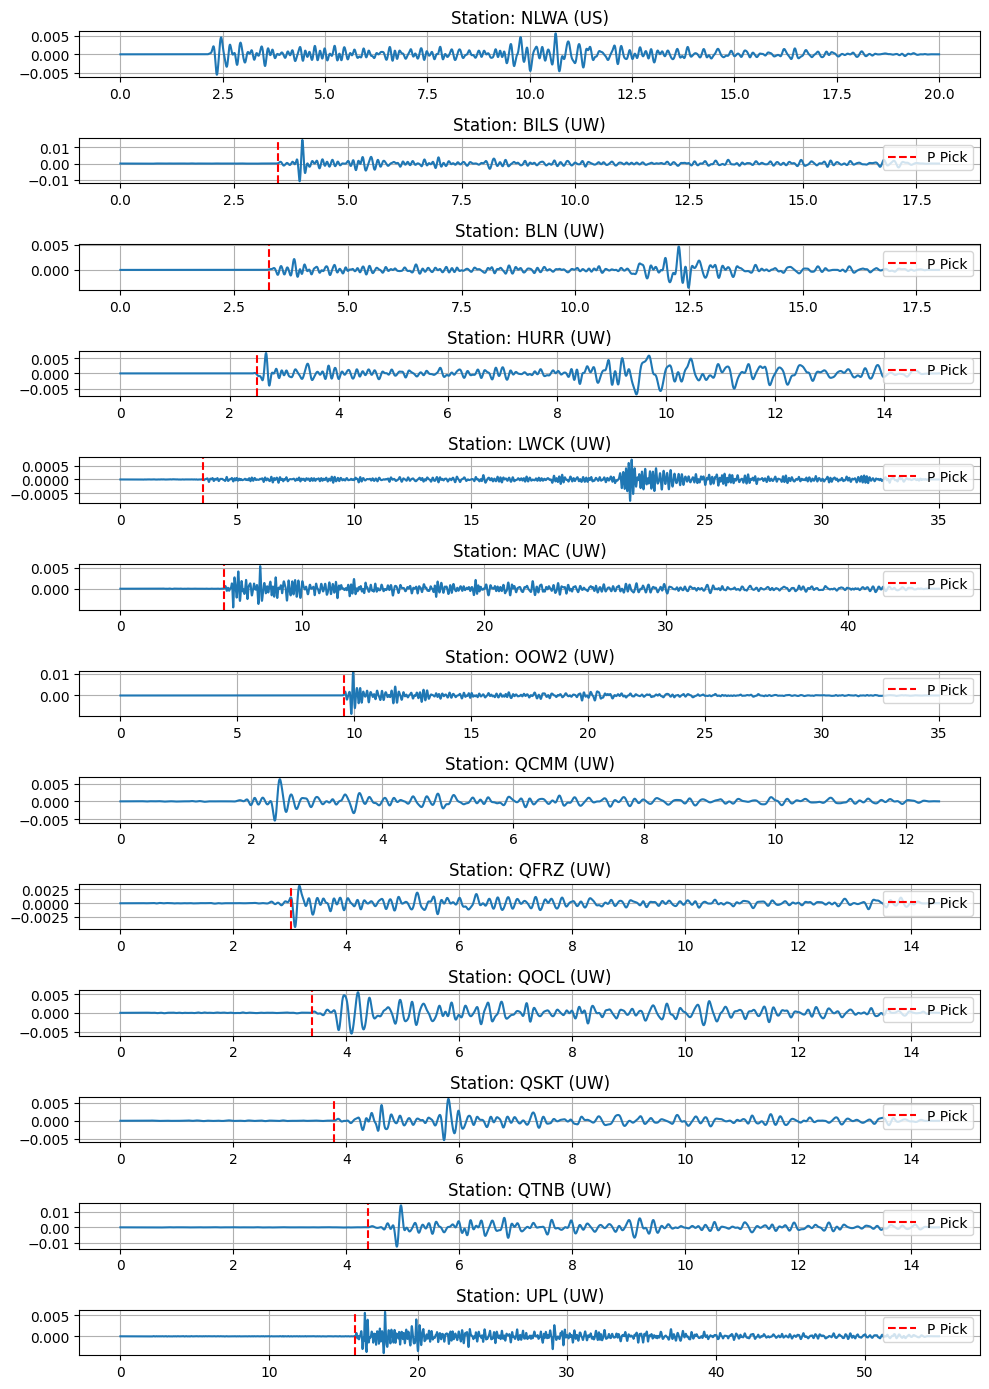

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, len(waveforms)+1))
for i in range(len(waveforms)):
    if p_picks[i] is not None:
        P_pick_sec = p_picks[i] - waveforms[i].stats.starttime   
    plt.subplot(len(waveforms), 1, i+1)
    plt.plot(waveforms[i].times(), waveforms[i].data)
    if p_picks[i] is not None:
        plt.axvline(x=P_pick_sec, color='r', linestyle='--', label='P Pick')
        plt.legend()
    plt.title(f"Station: {usable_df.iloc[i].station} ({usable_df.iloc[i].network})")
    plt.grid()
plt.tight_layout()

Here, assign a P arrival time for waveforms where PhaseNet failed to identify the P-arrival. Then visually confirm that that the picks have been assigned.

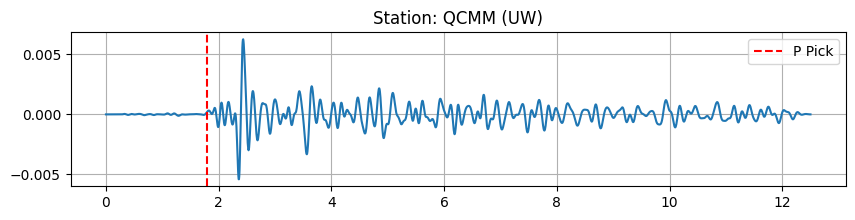

In [15]:
none_index = 7
new_pick = 1.8

picks = p_picks
picks[none_index] = waveforms[none_index].stats.starttime + new_pick

plt.figure(figsize=(10, 2))

plt.plot(waveforms[none_index].times(), waveforms[none_index].data)
plt.axvline(x=new_pick, color='r', linestyle='--', label='P Pick')
plt.legend()
plt.title(f"Station: {usable_df.iloc[none_index].station} ({usable_df.iloc[none_index].network})")
plt.grid()

Here, check if any waveform is without any P-arrival picks

In [ ]:
from obspy import UTCDateTime

for i, p in enumerate(picks):
    if p is None:
        raise ValueError(f"No P pick found for station {usable_df.iloc[i].station}.")

# use a nearby reference time
reference_time = min(picks)

pick_seconds_relative = np.array([pick_time - reference_time for pick_time in picks], dtype=float)

# Pairwise differential pick times:
# dt_mat[i, j] = pick_i - pick_j
dt_mat = (
    pick_seconds_relative[:, None]
    - pick_seconds_relative[None, :]
)

In [ ]:
import itertools

rows = []
data = []
pairs = []

for i, j in itertools.combinations(range(len(waveforms)), 2):
    if np.isnan(dt_mat[i, j]):
        continue

    row = np.zeros(len(waveforms))
    row[i] = 1.0
    row[j] = -1.0

    rows.append(row)
    data.append(dt_mat[i, j])
    pairs.append((i, j))

A = np.asarray(rows, dtype=float)
d = np.asarray(data, dtype=float)

if len(d) == 0:
    raise ValueError("No valid differential pick times were found.")

# Add the zero-mean constraint:
# t_1 + t_2 + ... + t_n = 0
constraint_weight = 10.0

A = np.vstack([
    A,
    np.ones(len(waveforms)) * constraint_weight
])

d = np.append(d, 0.0)

t_rel, _, _, _ = np.linalg.lstsq(
    A,
    d,
    rcond=None
)

# Remove any tiny numerical mean
t_rel -= np.mean(t_rel)

names = [waveform.stats.station for waveform in waveforms]

for name, delay in sorted(
    zip(names, t_rel),
    key=lambda item: item[1]
):
    print(f"{name:6s} {delay:+.4f} s")

HURR   -6.0831 s
NLWA   -4.8281 s
OOW2   -4.0431 s
BLN    -3.3231 s
BILS   -3.1231 s
QCMM   +0.8269 s
QOCL   +1.1269 s
QFRZ   +1.3119 s
QTNB   +1.5969 s
MAC    +2.1269 s
UPL    +2.2069 s
QSKT   +2.2469 s
LWCK   +9.9569 s


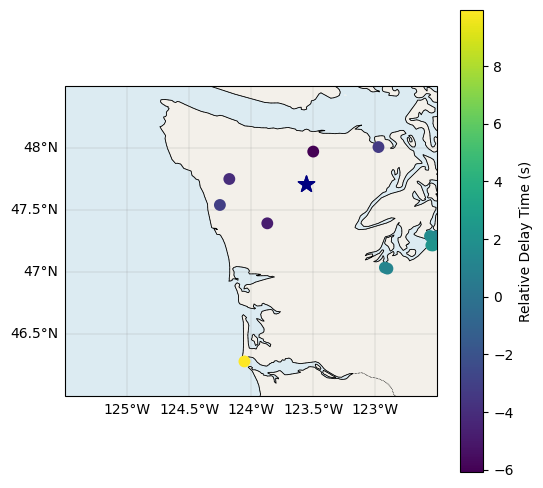

In [53]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
"""Add land/ocean/coastline context and frame the search box."""
min_lat, max_lat = 46, 48.5      # south / north edges
min_lon, max_lon = -125.5, -122.5  # west  / east  
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#f3f0ea")
ax.add_feature(cfeature.OCEAN, facecolor="#dcebf2")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.STATES, linestyle=":", linewidth=0.4)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = gl.right_labels = False

ax.scatter(event_lon, event_lat, marker="*", s = 150, color = "navy", 
           transform=ccrs.PlateCarree(), zorder=6)

ax.scatter(event_lon, event_lat, marker="*", s = 150, color = "navy", 
           transform=ccrs.PlateCarree(), zorder=6)

st_df_flt = st_df[st_df['qc_test']]
sc = ax.scatter(st_df_flt['longitude'], st_df_flt['latitude'], marker="o", s=40,
                   c = t_rel, linewidths=2.2,
                   transform=ccrs.PlateCarree(), zorder=5)
cbar = fig.colorbar(sc)
cbar.set_label("Relative Delay Time (s)")

#### **Correcting the Delay Map for Source–Station Distance**

The relative arrival-time map shown above contains two main influences:

1. **Source–station geometry:** stations farther from the earthquake generally record the P wave later because the wave travels a longer distance.
2. **Subsurface velocity structure:** P waves travel more slowly through low-velocity materials, such as sedimentary basins, and more quickly through higher-velocity crustal rocks.

To better isolate the effect of subsurface structure, we first estimate the arrival time expected from the earthquake-to-station distance. For this exercise, we assume that the P wave travels along a straight path through a homogeneous Earth with a constant velocity of:

$$V_P = 5.0\ \text{km/s}$$

The approximate hypocentral distance is calculated as:

$$D_{\mathrm{hypo}} =\sqrt{D_{\mathrm{horizontal}}^2 + D_{\mathrm{vertical}}^2}$$

where $D_{\mathrm{horizontal}}$ is the surface distance between the earthquake and station, and $D_{\mathrm{vertical}}$ is the vertical separation between the hypocenter and station.

The predicted P-wave travel time is then:

$$t_{\mathrm{pred}} = \frac{D_{\mathrm{hypo}}}{V_P}$$

Because the observed delays were calculated relative to the network average, the predicted travel times must also be converted to relative times before they are compared.

In [61]:
import numpy as np
from obspy.geodetics import gps2dist_azimuth

# ---------------------------------------------------------
# 1. Select stations that passed quality control
# ---------------------------------------------------------
st_df_flt = (
    st_df.loc[st_df["qc_test"]]
    .copy()
    .reset_index(drop=True)
)

# Convert the existing relative arrival times to an array
observed_relative_time = np.asarray(t_rel, dtype=float)

# Confirm that station and arrival-time arrays are aligned
if len(st_df_flt) != len(observed_relative_time):
    raise ValueError(
        "The number of QC-passed stations does not match the number of relative arrival times in t_rel."
    )

# ---------------------------------------------------------
# 2. Read earthquake information
# ---------------------------------------------------------
event_lat = event_selection["event_latitude"]
event_lon = event_selection["event_longitude"]
event_depth_km = event_selection["event_depth"]

# Constant P-wave velocity used for the simplified model
vp_km_s = 5.0

# ---------------------------------------------------------
# 3. Calculate horizontal source-station distances
# ---------------------------------------------------------
horizontal_distance_km = []

for station_lat, station_lon in zip(st_df_flt["latitude"],st_df_flt["longitude"]
):
    distance_m, _, _ = gps2dist_azimuth(event_lat, event_lon, station_lat, station_lon)

    horizontal_distance_km.append(distance_m / 1000.0)

horizontal_distance_km = np.asarray(horizontal_distance_km, dtype=float)

# ---------------------------------------------------------
# 4. Calculate vertical source-station separation
# ---------------------------------------------------------
# Event depth is positive downward.
# Station elevation is positive upward.
#
# Therefore, a station above sea level is slightly farther
# vertically from the hypocenter.

station_elevation_km = (st_df_flt["elevation"].to_numpy(dtype=float) / 1000.0)

vertical_distance_km = (event_depth_km + station_elevation_km)

# ---------------------------------------------------------
# 5. Calculate approximate hypocentral distance
# ---------------------------------------------------------
hypocentral_distance_km = np.sqrt(horizontal_distance_km**2 + vertical_distance_km**2)

# ---------------------------------------------------------
# 6. Predict P-wave travel time
# ---------------------------------------------------------
predicted_travel_time = (hypocentral_distance_km / vp_km_s)

# Add calculated quantities to the station dataframe
st_df_flt["horizontal_distance_km"] = horizontal_distance_km
st_df_flt["vertical_distance_km"] = vertical_distance_km
st_df_flt["hypocentral_distance_km"] = hypocentral_distance_km
st_df_flt["predicted_travel_time_s"] = predicted_travel_time
st_df_flt

,network,station,start_date,latitude,longitude,elevation,channel,sample_rate,data_available,gaps_detected,time_pick1,time_pick2,freqmin,freqmax,qc_test,horizontal_distance_km,vertical_distance_km,hypocentral_distance_km,predicted_travel_time_s
0,US,NLWA,2006-07-05T00:00:00.000000Z,47.391700,-123.869100,640.0,HNZ,200.0,True,False,80.0,100.0,2.0,8.0,True,42.717928,40.0600,58.563000,11.712600
1,UW,BILS,2015-03-30T00:00:00.000000Z,47.539660,-124.251380,62.0,HNZ,200.0,True,False,127.0,145.0,2.0,10.0,True,55.772755,39.4820,68.333217,13.666643
2,UW,BLN,1980-01-11T00:00:00.000000Z,48.006624,-122.972646,601.0,HNZ,200.0,True,False,127.0,145.0,2.0,9.0,True,54.511015,40.0210,67.624931,13.524986
3,UW,HURR,2017-05-10T00:00:00.000000Z,47.970350,-123.498710,1605.0,HNZ,200.0,True,False,125.0,140.0,0.5,10.0,True,29.096984,41.0250,50.295975,10.059195
4,UW,LWCK,2015-01-29T00:00:00.000000Z,46.277800,-124.053600,60.4,HNZ,200.0,True,False,140.0,175.0,4.0,10.0,True,163.831101,39.4804,168.521012,33.704202
5,UW,MAC,2018-06-25T00:00:00.000000Z,47.246700,-122.531800,112.5,HNZ,200.0,True,False,130.0,175.0,2.5,10.0,True,92.771080,39.5325,100.842907,20.168581
6,UW,OOW2,2015-03-03T00:00:00.000000Z,47.749190,-124.175440,741.0,HNZ,200.0,True,False,120.0,155.0,2.5,8.0,True,46.793465,40.1610,61.664693,12.332939
7,UW,QCMM,2011-05-20T00:00:00.000000Z,47.286380,-122.507650,90.2,HNZ,200.0,True,False,57.5,70.0,2.5,8.0,True,91.920272,39.5102,100.051948,20.010390
8,UW,QFRZ,2010-09-28T00:00:00.000000Z,47.034680,-122.920660,56.4,HNZ,200.0,True,False,55.5,70.0,2.5,10.0,True,89.154245,39.4764,97.503157,19.500631
9,UW,QOCL,2010-09-02T00:00:00.000000Z,47.026490,-122.900440,53.3,HNZ,200.0,True,False,55.5,70.0,2.5,7.5,True,90.747607,39.4733,98.960950,19.792190


#### **Converting the Predictions to Relative Arrival Times**

The previously calculated values in `t_rel` are relative arrival times. Their average is approximately zero because the inversion used a zero-mean constraint.

The absolute predicted travel times cannot be subtracted directly from these relative observations. First, the predicted times must be placed on the same relative reference:

$$t_{\mathrm{pred,rel},i} = t_{\mathrm{pred},i} - \overline{t_{\mathrm{pred}}}$$

The distance-corrected residual is then:

$$\delta t_i = t_{\mathrm{obs,rel},i} - t_{\mathrm{pred,rel},i}$$

where:

- $\delta t_i > 0$ indicates that the P wave arrived later than expected for the assumed 5 km/s velocity.
- $\delta t_i < 0$ indicates that the P wave arrived earlier than expected.
- $\delta t_i \approx 0$ indicates that the observed arrival is close to the constant-velocity prediction.

These residuals reduce the first-order influence of source–station distance and allow us to more clearly examine spatial variations associated with the travel path.

In [62]:
 # ---------------------------------------------------------
# 1. Ensure that the observed relative times have zero mean
# ---------------------------------------------------------
observed_relative_time = (observed_relative_time - np.mean(observed_relative_time))

# ---------------------------------------------------------
# 2. Convert predicted travel times to relative times
# ---------------------------------------------------------
predicted_relative_time = (predicted_travel_time- np.mean(predicted_travel_time))

# ---------------------------------------------------------
# 3. Calculate observed-minus-predicted residuals
# ---------------------------------------------------------
travel_time_residual = (observed_relative_time - predicted_relative_time)

# Remove any very small numerical mean
travel_time_residual -= np.mean(travel_time_residual)

# Store the results
st_df_flt["observed_relative_time_s"] = observed_relative_time
st_df_flt["predicted_relative_time_s"] = predicted_relative_time
st_df_flt["travel_time_residual_s"] = travel_time_residual

# Display the main results
result_columns = [
    "network",
    "station",
    "horizontal_distance_km",
    "hypocentral_distance_km",
    "predicted_travel_time_s",
    "observed_relative_time_s",
    "predicted_relative_time_s",
    "travel_time_residual_s"
]

st_df_flt[result_columns].round(3)

,network,station,horizontal_distance_km,hypocentral_distance_km,predicted_travel_time_s,observed_relative_time_s,predicted_relative_time_s,travel_time_residual_s
0,US,NLWA,42.718,58.563,11.713,-4.828,-6.349,1.521
1,UW,BILS,55.773,68.333,13.667,-3.123,-4.395,1.272
2,UW,BLN,54.511,67.625,13.525,-3.323,-4.537,1.214
3,UW,HURR,29.097,50.296,10.059,-6.083,-8.003,1.920
4,UW,LWCK,163.831,168.521,33.704,9.957,15.642,-5.685
5,UW,MAC,92.771,100.843,20.169,2.127,2.107,0.020
6,UW,OOW2,46.793,61.665,12.333,-4.043,-5.729,1.686
7,UW,QCMM,91.920,100.052,20.010,0.827,1.948,-1.121
8,UW,QFRZ,89.154,97.503,19.501,1.312,1.439,-0.127
9,UW,QOCL,90.748,98.961,19.792,1.127,1.730,-0.603


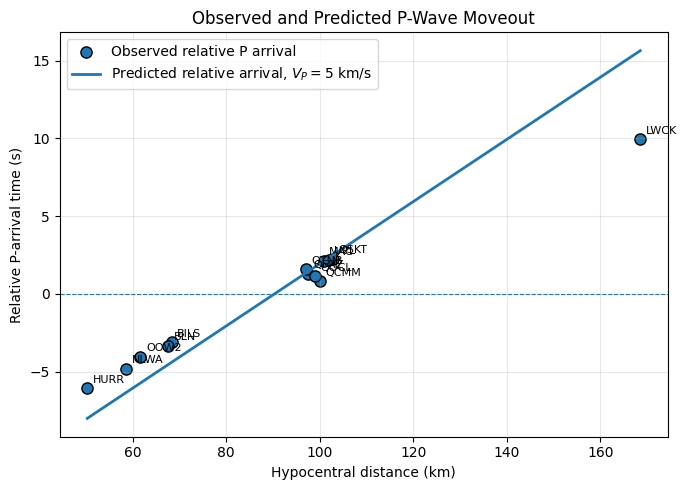

In [59]:
import matplotlib.pyplot as plt

distance_order = np.argsort(hypocentral_distance_km)

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    hypocentral_distance_km,
    observed_relative_time,
    s=65,
    edgecolor="black",
    label="Observed relative P arrival"
)

ax.plot(
    hypocentral_distance_km[distance_order],
    predicted_relative_time[distance_order],
    linewidth=2,
    label="Predicted relative arrival, $V_P = 5$ km/s"
)

for distance, arrival, station in zip(
    hypocentral_distance_km,
    observed_relative_time,
    st_df_flt["station"]
):
    ax.annotate(
        station,
        (distance, arrival),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

ax.axhline(
    0,
    linewidth=0.8,
    linestyle="--"
)

ax.set_xlabel("Hypocentral distance (km)")
ax.set_ylabel("Relative P-arrival time (s)")
ax.set_title("Observed and Predicted P-Wave Moveout")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

#### **Mapping the Distance-Corrected P-Wave Residuals**

The original map primarily showed relative arrival time. Consequently, stations farther from the earthquake tended to have more positive values, while stations close to the earthquake tended to have more negative values.

The corrected map instead shows the difference between the observed relative arrival time and the arrival time predicted from hypocentral distance:

$$\delta t = t_{\mathrm{obs,rel}} - t_{\mathrm{pred,rel}}$$

A positive residual means that the P wave arrived later than predicted by the constant 5 km/s model. This may be consistent with a greater proportion of the ray path traveling through relatively slow material, such as sedimentary basin deposits.

A negative residual means that the P wave arrived earlier than predicted. This may be consistent with a greater proportion of the ray path traveling through relatively fast, consolidated crustal rocks.

However, each residual represents the integrated effect of the entire earthquake-to-station ray path. It should not automatically be interpreted as the geology directly beneath the station.

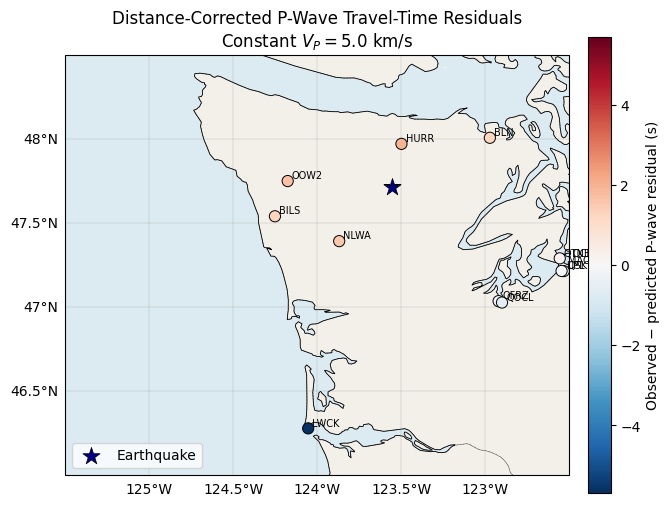

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib.colors import TwoSlopeNorm

event_lat = event_selection["event_latitude"]
event_lon = event_selection["event_longitude"]

# Values to map
t_residual = st_df_flt["travel_time_residual_s"].to_numpy()

# Use a symmetric color scale around zero
max_absolute_residual = np.nanmax(np.abs(t_residual))

norm = TwoSlopeNorm(vmin=-max_absolute_residual, vcenter=0.0, vmax=max_absolute_residual)

fig = plt.figure(figsize=(7, 6))

ax = fig.add_subplot(1,1,1,projection=ccrs.PlateCarree())

# Map extent
min_lat, max_lat = 46.0, 48.5
min_lon, max_lon = -125.5, -122.5

ax.set_extent(
    [min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree()
)

# Geographic context
ax.add_feature(cfeature.LAND, facecolor="#f3f0ea")
ax.add_feature(cfeature.OCEAN, facecolor="#dcebf2")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.STATES, linestyle=":",linewidth=0.4)

gridlines = ax.gridlines(draw_labels=True,linewidth=0.3,color="gray",alpha=0.5)

gridlines.top_labels = False
gridlines.right_labels = False

# Plot earthquake
ax.scatter(event_lon, event_lat, marker="*", s=170, color="navy", edgecolor="black", linewidth=0.5,
                transform=ccrs.PlateCarree(), label="Earthquake", zorder=6)

# Plot station residuals
scatter = ax.scatter(st_df_flt["longitude"], st_df_flt["latitude"], c=t_residual,
                cmap="RdBu_r", norm=norm, marker="o", s=65, edgecolor="black", linewidth=0.7,
                transform=ccrs.PlateCarree(), zorder=5)

# Add station labels
for _, station in st_df_flt.iterrows():
    ax.text(station["longitude"] + 0.025, station["latitude"] + 0.015, station["station"],
            fontsize=7, transform=ccrs.PlateCarree(), zorder=7)

colorbar = fig.colorbar(scatter, ax=ax, pad=0.03, shrink=0.8)

colorbar.set_label("Observed − predicted P-wave residual (s)")

ax.set_title(
    "Distance-Corrected P-Wave Travel-Time Residuals\n"
    "Constant $V_P = 5.0$ km/s"
)

ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

The crude interpretation of delay map plot: 
- The stations with negetive travel time residuals should have Vp lower than 5
- The stations with zero travel time residuals should have Vp similar to 5
- The stations with positive travel time residuals should have Vp higher to 5

## **2. Output comparison**

#### **2.1 Modify processing parameters**

Recipe A: default filter from Notebook 2

Recipe B: narrower bandpass

Recipe C: wider bandpass or different frequency band

For each recipe, rerun:
filtering → picking → SNR → cross-correlation → delay-time plot

#### **2.2 Compare results**

Suggested comparison table:

| Processing recipe | Stations kept | Median P SNR | Median P probability | Median correlation | Notes |
| :---------------: | :-----------: | :----------: | :------------------: | :----------------: | :---: |
| Default filter ||||||
| Narrower Bandpass ||||||
| Wider Bandpass ||||||

#### **2.3 Decide which waveforms are acceptable**

Purpose: Formalize final QC and dataset refinement

## **Reflection**

In a local traditional workflow, changing the event, station list, time window, or filter band may require repeated downloads, repeated local file management, and repeated processing. That slows down the exploratory part of seismic science.

In GeoLab, the workflow is easier to iterate. We can stream or retrieve selected waveform windows, apply a processing recipe, compare outputs, revise parameters, and update the station list in the same environment. This makes the scientific workflow more flexible: instead of committing too early to a fixed downloaded dataset, we can use metadata, waveform QC, and scientific outputs together to decide which data are useful.